# The national tasking tool on the Irish Tellus soil survey

This notebook demonstrates the workflow on one uploaded point dataset. The
user uploads the surveyed point measurements, and the run binarizes the
measurement at a declared threshold to define the class. The workflow fits an
RF classifier to that class, delivers the class-probability raster, and
estimates the extent of the class in hectares with a confidence interval. The
run prints its accuracy on the held-out blocks below, and the delivered
tables carry the same metrics. The block partition prints below as counts and
a map, and the delivered tables carry the block counts.

1. Assign each point to a 10 km block.
2. Sample the 64 embedding bands at the points.
3. Hold out a quarter of the blocks.
4. Fit the random forest on the class.
5. Score the held-out blocks.
6. Predict over the blocks holding reference points for the year the survey
   describes.
7. Estimate the extent with a confidence interval.
8. Export the delivery.


## Dependencies and case study variables


In [1]:
import time
from collections import Counter

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def log(message):
    print(f"  {time.strftime('%H:%M:%S')}  {message}")


EE_PROJECT = 'asc-coh-april-2021-2022'   # a Cloud project registered for Earth Engine
ee.Initialize(project=EE_PROJECT)

/Users/coreyscher/miniforge3/lib/python3.12/site-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


In [2]:
# ---- the case -------------------------------------------------------------
POINTS_ASSET   = 'projects/asc-coh-april-2021-2022/assets/orbit_unops/tellus_shallow_topsoil_A_loi'
SAMPLE_ASSET   = 'projects/asc-coh-april-2021-2022/assets/orbit_tasking/irl_loi_2018_two_paths_sample'
WEIGHTS_ASSET  = 'projects/asc-coh-april-2021-2022/assets/orbit_tasking/irl_loi_2018_two_paths'  # prefix for the three step-7 scratch tables
BUCKET         = 'orbit-tasking-demo'   # Cloud Storage bucket the delivery is written to; empty skips the raster export
SUBMIT_EXPORTS  = False   # the pipeline's --no-export; batch submissions start only when True
DELIVERY_PREFIX = 'irl-loi-2018-two-paths'   # names this run inside the bucket

LABEL_PROP     = 'PEAT_CLASS'   # the property carrying the label
POSITIVE_CLASS = 'peat'         # the value of LABEL_PROP that means "present"
LABEL_IS_BINARY = False         # True if LABEL_PROP is already 0/1 and needs no comparison

# The national boundary comes from the FAO GAUL 2015 level-0 collection in
# the Earth Engine catalog. Any boundary collection or uploaded boundary
# asset works. A production run should use the highest-resolution national
# boundary available.
BOUNDARY_COLLECTION = 'FAO/GAUL/2015/level0'
BOUNDARY_ADM0_NAME  = 'Ireland'

LABEL_YEAR     = 2018           # the year the field survey data describes
PREDICT_YEAR   = 2018           # the year of embeddings to predict over; kept
                                # separate so a later year can be predicted
                                # from the same fit
COUNTRY_CRS    = 'EPSG:2157'    # the projection the block grid is built in; here
                                # Irish Transverse Mercator

# ---- method configuration -------------------------------------------------

BLOCK_M          = 10_000       # spatial block size in meters. Blocks are the
                                # unit of the hold-out and the bootstrap; the
                                # reasoning is in step 3.
TEST_FRACTION    = 0.25         # share of blocks held out
SEED             = 42           # test draw and model. frozen

DRAWS            = 10       # block-bootstrap draws in step 5b. The spread of
                            # test scores across draws measures how much the
                            # accuracy depends on which blocks the survey
                            # happened to cover. 10 keeps the cost modest;
                            # more draws give a smoother band.

COLLECTION       = 'GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL'
N_BANDS          = 64
SCALE_M          = 10           # sampling and prediction resolution, meters
TREES            = 200
VARS_PER_SPLIT   = 64           # all bands considered at each split; step 4
                                # states why this is not Earth Engine's default
BAG_FRACTION     = 1.0          # full bootstrap per tree

# level of the step-7 area interval (Olofsson Eq. 11)
# sets z = 1.96. Does not affect the step-5 bootstrap band.
CONFIDENCE       = 0.95


PROBABILITY_SCALE = 10_000      # probability to unsigned 16-bit at export

BANDS = [f'A{i:02d}' for i in range(N_BANDS)]

## User uploaded data

Here the user references their own point-level dataset, one
`ee.FeatureCollection` with one feature per reference observation that carries
the measurement. For this notebook it is the Tellus shallow
topsoil table with `LOI_PCT` (percent loss on ignition at 450 degrees C).
Points outside the national boundary named above are dropped at ingest, and
the dropped count is printed.

From this one column the run derives the class: `y` is 1 where the measurement
is at or above the threshold declared below. The workflow ships the
class-probability raster and estimates the extent of the class in hectares
with a confidence interval (Olofsson et al. 2014).

We binarize the LOI data to define the peat class by thresholding
`LOI_PCT` at the value declared in the next cell, in code. The threshold is
the class definition.


In [3]:
# ---- the class from the measured column ----------------------------------
MEASUREMENT_PROP = 'LOI_PCT'   # the continuous column as surveyed
CLASS_NAME       = 'peat'      # what the positive class is called in outputs

# We binarize the LOI data to define the peat class by thresholding LOI_PCT
# at this value. 
CUT              = 30.0

# LABEL_PROP, POSITIVE_CLASS and LABEL_IS_BINARY in the case cell above apply
# when the upload is already a class column. This notebook uploads the
# measurement itself, so they are not used.

# pipeline counterpart: pipeline/tasking/target.py; the label reduction in pipeline/tasking/run.py run()


In [4]:
points_raw = ee.FeatureCollection(POINTS_ASSET)
n_uploaded = points_raw.size().getInfo()

boundary = ee.FeatureCollection(BOUNDARY_COLLECTION) \
             .filter(ee.Filter.eq('ADM0_NAME', BOUNDARY_ADM0_NAME))
points_raw = points_raw.filterBounds(boundary.geometry())
n_raw = points_raw.size().getInfo()
log(f'{n_uploaded:,} points uploaded, {n_uploaded - n_raw:,} outside '
    f'{BOUNDARY_ADM0_NAME} dropped, {n_raw:,} kept')


def to_targets(feature):
    """The class from the measured column: y is 1 where the measurement is at or above CUT."""
    value = ee.Number(feature.get(MEASUREMENT_PROP))
    return feature.set('y', value.gte(CUT).int())


points_raw = points_raw.map(to_targets)
stats = points_raw.aggregate_stats(MEASUREMENT_PROP).getInfo()
log(f"{MEASUREMENT_PROP}: mean {stats['mean']:.1f}, "
    f"min {stats['min']:.1f}, max {stats['max']:.1f}")
prevalence = points_raw.aggregate_mean('y').getInfo()
log(f'{prevalence:.3f} of points are {CLASS_NAME!r} at the {CUT:g} percent loss on ignition binary cut')

# pipeline counterpart: pipeline/tasking/run.py run(), where the label column is reduced to y


/Users/coreyscher/miniforge3/lib/python3.12/site-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


  18:08:36  16,779 points uploaded, 7,118 outside Ireland dropped, 9,661 kept


  18:08:37  LOI_PCT: mean 33.6, min 0.6, max 99.9


  18:08:38  0.323 of points are 'peat' at the 30 percent loss on ignition binary cut


## Assign each point to a 10 km block

Here the run assigns each point to a 10 km block and prints the count of
blocks holding at least one point. It projects each point into the country's
grid CRS and floor-divides the meters by the block size, so the id is
`"<col>_<row>"` and two points share a block exactly when they fall in the
same 10 km cell.

The block is the unit the workflow holds out, resamples and reports over.

`ee.Geometry.transform` takes a maximum reprojection error (one meter here),
so a point lying within a meter of a block edge could be assigned to the
neighboring block


In [5]:
def with_block_id(feature):
    xy = ee.List(feature.geometry().transform(COUNTRY_CRS, 1).coordinates())
    col = ee.Number(xy.get(0)).divide(BLOCK_M).floor().int()
    row = ee.Number(xy.get(1)).divide(BLOCK_M).floor().int()
    return feature.set('block_id', col.format('%d').cat('_').cat(row.format('%d')))


labelled = points_raw.map(with_block_id).select(['block_id', 'y'])
log(f'{labelled.aggregate_count_distinct("block_id").getInfo()} blocks of '
    f'{BLOCK_M // 1000} km hold at least one point')

# pipeline counterpart: pipeline/tasking/grid.py to_projected, block_ids


  18:08:43  447 blocks of 10 km hold at least one point


## Sample the AlphaEarth embeddings at the points

The run prints how many points returned a value from the satellite record.
The predictors are the 64 bands of the annual satellite embedding for the
label year (Brown et al. 2025), read at 10 m.

Filter to the region, then mosaic.

A point whose pixel is masked returns nothing and drops out. The count that
disappears is printed below.

### Materialize the sample once

The run writes the sample to a table asset once, and every later step reads
that table. Sampling is lazy. If sampling is left as a server-side
computation, every model fit below would re-run `sampleRegions` over every
point, and a block drawn twice in a bootstrap draw would sample its points
twice again inside that. One request for the whole table exceeds Earth
Engine's payload limit and is rejected with
`Request payload size exceeds the limit: 10485760 bytes`, so the run pulls
the sampled bands to the client in chunks of 2,000 points. It stages the
assembled table to the Cloud Storage bucket as CSV and ingests the staged
file as the table asset. Later runs reuse the asset and read the staged table back from the bucket.


In [6]:
def embedding_for(year, region=None):
    """The annual embedding mosaic for one year, as a single 64-band image."""
    collection = ee.ImageCollection(COLLECTION).filterDate(
        f'{year}-01-01', f'{year + 1}-01-01')
    if region is not None:
        collection = collection.filterBounds(region)
    return collection.mosaic().select(BANDS)


# pipeline counterpart: pipeline/tasking/features.py collection, sample


In [7]:
name = SAMPLE_ASSET.rsplit('/', 1)[-1]
blob = f'_tasking_staging/{name}.csv'
chunk = 2000                           # the pipeline's features.sample_chunk


def asset_exists(asset_id):
    try:
        ee.data.getAsset(asset_id)
        return True
    except Exception:
        return False


if asset_exists(SAMPLE_ASSET):
    # The staged table is the exact table that became the asset, so a rerun
    # reads it back from the bucket.
    import io
    from google.cloud import storage
    data = storage.Client().bucket(BUCKET).blob(blob).download_as_bytes()
    sample_frame = pd.read_csv(io.BytesIO(data))
    log(f'reusing {SAMPLE_ASSET}: staged table read back, '
        f'{len(sample_frame):,} points')
else:
    # The sampled table is built the way the pipeline builds it: the bands are
    # pulled in chunks inside the interactive payload ceiling, the table is
    # staged to the bucket, and the staged file is ingested as the table asset.
    def as_row(el):
        feature = ee.Feature(el)
        return feature.geometry().coordinates().cat(
            [feature.get('block_id'), feature.get('y')])

    point_rows = []
    for start in range(0, n_raw, chunk):
        point_rows.extend(labelled.toList(chunk, start).map(as_row).getInfo())
        log(f'pulled {min(start + chunk, n_raw):,} of {n_raw:,} points')
    frame_pts = pd.DataFrame(
        point_rows, columns=['lon', 'lat', 'block_id', 'y'])

    img = embedding_for(LABEL_YEAR, labelled.geometry().bounds())
    band_rows = []
    for start in range(0, len(frame_pts), chunk):
        part = frame_pts.iloc[start:start + chunk]
        fc = ee.FeatureCollection([
            ee.Feature(ee.Geometry.Point([row.lon, row.lat]), {'i': int(i)})
            for i, row in part.iterrows()])
        sampled_part = img.sampleRegions(collection=fc, properties=['i'],
                                         scale=SCALE_M, geometries=False,
                                         tileScale=4).getInfo()['features']
        band_rows.extend(f['properties'] for f in sampled_part)
        log(f'sampled {min(start + chunk, len(frame_pts)):,} of '
            f'{len(frame_pts):,} points')

    # sampleRegions drops points on embedding nodata, so the join keeps the
    # points that returned bands. The pipeline joins the same way.
    band_frame = pd.DataFrame(band_rows).set_index('i')
    sample_frame = frame_pts.join(band_frame[BANDS], how='inner')

    import pathlib
    import tempfile
    from google.cloud import storage
    columns = ['lon', 'lat', 'block_id', 'y'] + BANDS
    with tempfile.TemporaryDirectory() as tmp:
        local = pathlib.Path(tmp) / f'{name}.csv'
        sample_frame[columns].to_csv(local, index=False)
        storage.Client().bucket(BUCKET).blob(blob).upload_from_filename(str(local))
    log(f'staged {len(sample_frame):,} rows to gs://{BUCKET}/{blob}')

    request_id = ee.data.newTaskId()[0]
    manifest = {
        'name': ee.data.convert_asset_id_to_asset_name(SAMPLE_ASSET),
        'sources': [{'uris': [f'gs://{BUCKET}/{blob}'],
                     'x_column': 'lon', 'y_column': 'lat', 'crs': 'EPSG:4326'}],
    }
    operation = ee.data.startTableIngestion(request_id, manifest)
    log(f'ingesting -> {SAMPLE_ASSET}')
    op_name = operation.get('name') or operation['id']
    while not ee.data.getOperation(op_name).get('done'):
        time.sleep(5)
    final = ee.data.getOperation(op_name)
    assert 'error' not in final, f'ingestion failed: {final.get("error")}'

points = ee.FeatureCollection(SAMPLE_ASSET)
n_sampled = len(sample_frame)

log(f'{n_raw - n_sampled:,} points fell on embedding nodata and were dropped')

# pipeline counterpart: pipeline/tasking/features.py sample, sampled_asset;
# pipeline/tasking/assets.py exists, stage_table, ingest_table


  18:08:44  reusing projects/asc-coh-april-2021-2022/assets/orbit_tasking/irl_loi_2018_two_paths_sample: staged table read back, 9,661 points
  18:08:44  0 points fell on embedding nodata and were dropped


## Hold out blocks

The run holds out blocks and prints the partition below. **The held-out unit
is the block.** Points a few kilometers apart share spatial autocorrelation
with the embedding, so a random point split measures interpolation rather
than generalization (Ploton et al. 2020; Valavi et al. 2019). A random point split is not offered.

The draw has three rules:

1. Every block holding at least one point is eligible.
2. A quarter of the blocks are drawn as the fixed test set, unstratified, at
   seed 42. The split fixes the held-out ground.
3. Every point inside a test block is a test point.

The split is computed on the client, from the block ids of the sample table
read back from the bucket. The 64 bands stay on the server.


In [8]:
frame = sample_frame[['block_id']].copy()

blocks = np.sort(frame.block_id.unique())
rng = np.random.default_rng(SEED)
k = int(round(TEST_FRACTION * len(blocks)))
# Blocks are drawn by simple random sampling at a fixed seed.
test_blocks = sorted(set(rng.choice(blocks, size=k, replace=False)))
train_blocks = [b for b in blocks if b not in set(test_blocks)]

in_test = frame.block_id.isin(set(test_blocks))
log(f'{len(train_blocks)} training blocks, {(~in_test).sum():,} points')
log(f'{len(test_blocks)} held-out blocks, {in_test.sum():,} points')

train_fc = points.filter(ee.Filter.inList('block_id', sorted(train_blocks)))
test_fc = points.filter(ee.Filter.inList('block_id', test_blocks))

# pipeline counterpart: pipeline/tasking/partition.py partition


  18:08:44  335 training blocks, 7,194 points
  18:08:44  112 held-out blocks, 2,467 points


### Map the training and held-out blocks

Here the user sees their dataset split into blocks, training and held out. The
figure draws the 10 km blocks on the Irish grid, colored by side of the
split, with the counts in the legend. Every accuracy figure that follows is
measured on the held-out blocks.


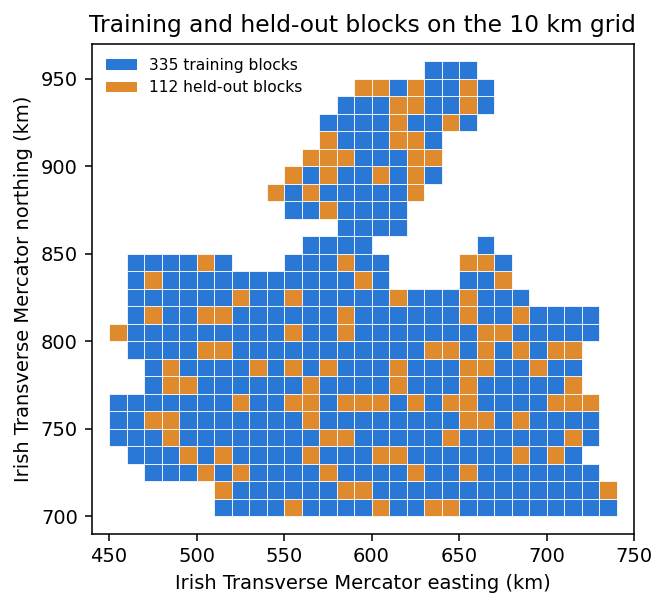

In [9]:
from matplotlib.patches import Patch

test_set = set(test_blocks)
km = BLOCK_M / 1000.0
cols_rows = [tuple(int(v) for v in str(b).split('_')) for b in blocks]

fig, ax = plt.subplots(figsize=(5.0, 6.4), dpi=140)
for (col, row), bid in zip(cols_rows, blocks):
    ax.add_patch(plt.Rectangle(
        (col * km, row * km), km, km,
        facecolor='#e08a2e' if bid in test_set else '#2a78d6',
        edgecolor='white', linewidth=0.4))
xs = [c for c, _ in cols_rows]
ys = [r for _, r in cols_rows]
ax.set_xlim(min(xs) * km - km, (max(xs) + 2) * km)
ax.set_ylim(min(ys) * km - km, (max(ys) + 2) * km)
ax.set_aspect('equal')
ax.legend(handles=[
    Patch(facecolor='#2a78d6', label=f'{len(train_blocks)} training blocks'),
    Patch(facecolor='#e08a2e', label=f'{len(test_blocks)} held-out blocks')],
    loc='upper left', frameon=False, fontsize=8)
ax.set_xlabel('Irish Transverse Mercator easting (km)')
ax.set_ylabel('Irish Transverse Mercator northing (km)')
ax.set_title('Training and held-out blocks on the 10 km grid')
plt.show()

# pipeline counterpart: none yet


## Train

The frozen forest trains on `y` (Breiman 2001). The forest grows two hundred trees at seed
42, considers all 64 variables at each split, and takes a full bootstrap per
tree.

Class probability is the mean posterior across the trees. The hard class is
`argmax`, which is the trees' majority vote. There is no tuned threshold. A
threshold tuned out of bag is not buildable in Earth Engine, whose
`explain()` returns no per-sample out-of-bag output.

**Two parameters are not Earth Engine's defaults.** Earth Engine defaults to
`variablesPerSplit = sqrt(n)` and `bagFraction = 0.5`. This workflow considers
all 64 at each split with a full bootstrap, matching the scikit-learn
configuration the method was developed with, so results reproduce across the
two implementations.

**One model ships.** It is fitted once on the whole training set. The hard
class feeds only the stratum weights under the extent estimate. The bootstrap
draws in the sensitivity band never ship.


In [10]:
def forest(mode):
    """The frozen random forest. mode: PROBABILITY or CLASSIFICATION."""
    return ee.Classifier.smileRandomForest(
        numberOfTrees=TREES, variablesPerSplit=VARS_PER_SPLIT,
        bagFraction=BAG_FRACTION, seed=SEED).setOutputMode(mode)


def train(collection, mode='PROBABILITY'):
    """Train on the class y."""
    return forest(mode).train(
        features=collection, classProperty='y', inputProperties=BANDS)


product_model = train(train_fc, 'PROBABILITY')      # the model that ships
hard_model = train(train_fc, 'CLASSIFICATION')      # the argmax model for the step 7A weights
log(f'{TREES} trees, variablesPerSplit {VARS_PER_SPLIT}, '
    f'bagFraction {BAG_FRACTION}, seed {SEED}')

# pipeline counterpart: pipeline/tasking/train.py classifier, regressor, train


  18:08:44  200 trees, variablesPerSplit 64, bagFraction 1.0, seed 42


## Evaluate on the held-out blocks

Here the run prints the receiver operating characteristic with the accuracy
metrics and a one-sentence summary, so the user can judge whether the product
classifies well.

The run reports AUC in the Mann-Whitney rank form (Mann and Whitney 1947)
with ties at average ranks,
plus the confusion-matrix family at the half-probability threshold, kept
distinct from the majority-vote class behind the stratum weights.


In [11]:
def auc(y_true, prob):
    """Area under the ROC by rank, ties averaged."""
    positive, negative = y_true == 1, y_true == 0
    n_pos, n_neg = int(positive.sum()), int(negative.sum())
    if n_pos == 0 or n_neg == 0:
        return float('nan')
    order = np.argsort(prob, kind='mergesort')
    ranks = np.empty(len(prob), dtype=float)
    ranks[order] = np.arange(1, len(prob) + 1)
    ranks = pd.DataFrame({'p': prob, 'r': ranks}).groupby('p')['r']               .transform('mean').to_numpy()
    return float((ranks[positive].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


def metrics(y_true, prob, draw=0):
    """Confusion metrics at the half-probability threshold, plus AUC.

    The map's stratum weights in step 7A use the server-side argmax class
    instead. The mean posterior thresholded at one half and the majority vote
    across trees can differ on points near 0.5, so the two are kept distinct.
    """
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob, dtype=float)
    pred = (prob >= 0.5).astype(int)

    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())

    tpr = tp / (tp + fn) if (tp + fn) else float('nan')
    fpr = fp / (fp + tn) if (fp + tn) else float('nan')
    precision = tp / (tp + fp) if (tp + fp) else float('nan')
    f1 = (2 * precision * tpr / (precision + tpr)) if (precision and tpr) else float('nan')
    reference_share = float(y_true.mean())

    return dict(draw=draw, n_test=len(y_true), auc=auc(y_true, prob), f1=f1,
                tpr=tpr, fpr=fpr,
                producer_accuracy=tpr, user_accuracy=precision,
                overall_accuracy=(tp + tn) / len(y_true),
                map_positive_share=float(pred.mean()),
                area_share_error=(float(pred.mean()) - reference_share) / reference_share)


def score(fitted, collection=None):
    """Classify the held-out points and pull back probability and truth."""
    collection = test_fc if collection is None else collection
    got = collection.classify(fitted).getInfo()['features']
    return (np.array([f['properties']['y'] for f in got], dtype=int),
            np.array([f['properties']['classification'] for f in got], dtype=float),
            pd.Series([f['properties']['block_id'] for f in got]))


# pipeline counterpart: pipeline/tasking/evaluate.py _auc, score


### Score the model that ships

Here the run computes the accuracy the delivery carries. The shipped model is
fitted once on all training blocks and scored on the same held-out points the
draws use.


In [12]:
y_ship, p_ship, block_ship = score(product_model)
shipped = metrics(y_ship, p_ship, draw=-1)
log(f'shipped fit: AUC {shipped["auc"]:.4f}  F1 {shipped["f1"]:.4f}  '
    f'overall accuracy {shipped["overall_accuracy"]:.4f}  n {shipped["n_test"]:,}')
log(f"  producer's accuracy {shipped['producer_accuracy']:.4f}  "
    f"user's accuracy {shipped['user_accuracy']:.4f}")


# pipeline counterpart: the shipped-fit scoring in pipeline/tasking/run.py run()


  18:08:46  shipped fit: AUC 0.9445  F1 0.8472  overall accuracy 0.9035  n 2,467
  18:08:46    producer's accuracy 0.7981  user's accuracy 0.9029


/Users/coreyscher/miniforge3/lib/python3.12/site-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


### Bootstrap blocks to measure survey sensitivity

Training **blocks** are resampled with replacement and the model refitted.
This is the cluster form of the bootstrap (Efron 1979; Davison and Hinkley
1997), treating the block rather than the point as the sampling unit. A block
drawn twice contributes its points twice. A `FeatureCollection` filter cannot
express a repeat, so the draw is built by multiplicity, grouping the drawn
blocks by how many times each was drawn and merging each group that many
times.

About 63 percent of blocks are unique in any one draw, which is `1 - 1/e`, so
a draw holds as many block slots as the pool but fewer distinct blocks. The
spread across draws measures the sensitivity of the score to which blocks the
survey happened to contain, and appears as the band on the figure below. The
accuracy of the delivered map is the shipped score above.


In [13]:
def bootstrap_blocks(train_blocks, draws=DRAWS):
    """Block bootstrap of the training set, seeds 0 to draws-1. Repeats are kept."""
    pool = np.sort(np.asarray(train_blocks))
    out = []
    for draw in range(draws):
        rng = np.random.default_rng(draw)
        out.append(list(rng.choice(pool, size=len(pool), replace=True)))
    return out


def bootstrap_fc(collection, drawn_blocks):
    """One draw's training collection, with repeated blocks repeated."""
    by_multiplicity = {}
    for block, m in Counter(drawn_blocks).items():
        by_multiplicity.setdefault(m, []).append(block)
    out = None
    for m, members in sorted(by_multiplicity.items()):
        part = collection.filter(ee.Filter.inList('block_id', sorted(members)))
        for _ in range(m):
            out = part if out is None else out.merge(part)
    return out

# pipeline counterparts: pipeline/tasking/partition.py training_bootstrap; pipeline/tasking/train.py bootstrap_fc

In [14]:
started = time.time()
draws = bootstrap_blocks(train_blocks)
per_draw, roc_curves = [], []

for i, drawn in enumerate(draws):
    model = train(bootstrap_fc(train_fc, drawn), 'PROBABILITY')
    y_d, p_d, _ = score(model)
    m = metrics(y_d, p_d, draw=i)
    per_draw.append(m)

    order = np.argsort(-p_d, kind='mergesort')
    tp = np.cumsum(y_d[order] == 1) / max(int((y_d == 1).sum()), 1)
    fp = np.cumsum(y_d[order] == 0) / max(int((y_d == 0).sum()), 1)
    roc_curves.append((np.r_[0, fp], np.r_[0, tp]))
    log(f'draw {i}: AUC {m["auc"]:.4f}  F1 {m["f1"]:.4f}  n {m["n_test"]:,}')

table = pd.DataFrame(per_draw)
summary = pd.DataFrame({
    'median': table.median(numeric_only=True),
    'p10': table.quantile(0.10, numeric_only=True),
    'p90': table.quantile(0.90, numeric_only=True)}).drop(index=['draw', 'n_test'])
log(f'{DRAWS} draws in {time.time() - started:.0f} s')
print(summary.round(4))

# pipeline counterpart: the draw loop in pipeline/tasking/run.py run()


/Users/coreyscher/miniforge3/lib/python3.12/site-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


  18:08:47  draw 0: AUC 0.9395  F1 0.8458  n 2,467


/Users/coreyscher/miniforge3/lib/python3.12/site-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


  18:08:50  draw 1: AUC 0.9414  F1 0.8444  n 2,467


/Users/coreyscher/miniforge3/lib/python3.12/site-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


...

  18:08:59  draw 7: AUC 0.9410  F1 0.8380  n 2,467


/Users/coreyscher/miniforge3/lib/python3.12/site-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


  18:09:01  draw 8: AUC 0.9403  F1 0.8380  n 2,467


  18:09:02  draw 9: AUC 0.9407  F1 0.8405  n 2,467
  18:09:02  10 draws in 17 s
                    median     p10     p90
auc                 0.9411  0.9395  0.9439
f1                  0.8415  0.8380  0.8462
tpr                 0.7914  0.7868  0.7964
fpr                 0.0448  0.0409  0.0470
producer_accuracy   0.7914  0.7868  0.7964
user_accuracy       0.8990  0.8943  0.9068
overall_accuracy    0.9001  0.8986  0.9030
map_positive_share  0.2957  0.2917  0.2979
area_share_error   -0.1179 -0.1299 -0.1112


/Users/coreyscher/miniforge3/lib/python3.12/site-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


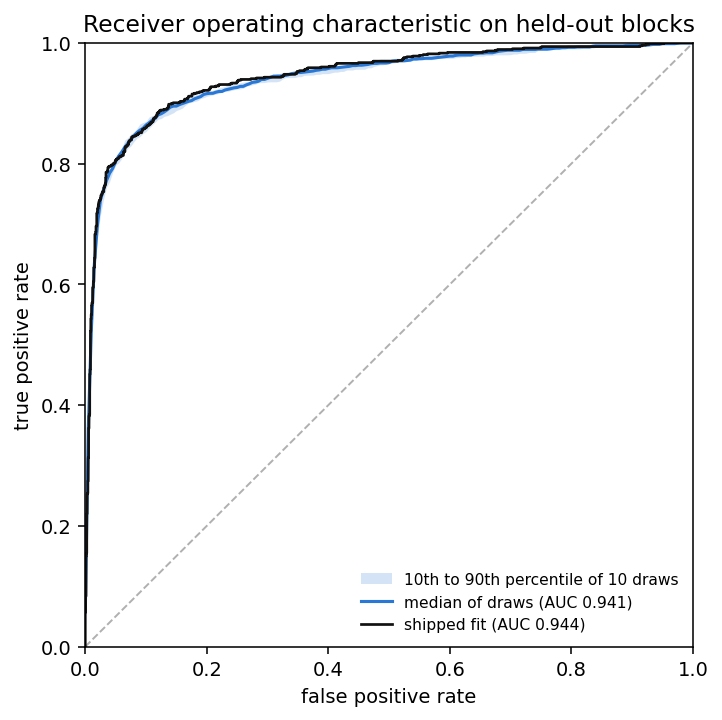

Model evaluated. AUC 0.941 (10th–90th percentile 0.939–0.944). F1 0.841.


In [15]:
grid_fp = np.linspace(0, 1, 201)
curves = np.vstack([np.interp(grid_fp, f, t) for f, t in roc_curves])
ship_order = np.argsort(-p_ship, kind='mergesort')
ship_tp = np.cumsum(y_ship[ship_order] == 1) / max(int((y_ship == 1).sum()), 1)
ship_fp = np.cumsum(y_ship[ship_order] == 0) / max(int((y_ship == 0).sum()), 1)

fig, ax = plt.subplots(figsize=(5.6, 5.6), dpi=140)
ax.plot([0, 1], [0, 1], ls='--', lw=1, color='#b0b0b0')
ax.fill_between(grid_fp, np.percentile(curves, 10, axis=0),
                np.percentile(curves, 90, axis=0), color='#2a78d6', alpha=0.20,
                lw=0, label=f'10th to 90th percentile of {DRAWS} draws')
ax.plot(grid_fp, np.median(curves, axis=0), color='#2a78d6', lw=1.6,
        label=f'median of draws (AUC {np.median(table["auc"]):.3f})')
ax.plot(np.r_[0, ship_fp], np.r_[0, ship_tp], color='#111111', lw=1.4,
        label=f'shipped fit (AUC {shipped["auc"]:.3f})')
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('Receiver operating characteristic on held-out blocks')
ax.legend(loc='lower right', frameon=False, fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.show()

print('Model evaluated. AUC {auc_median:.3f} (10th–90th percentile '
      '{auc_p10:.3f}–{auc_p90:.3f}). F1 {f1_median:.3f}.'.format(
          auc_median=np.median(table['auc']),
          auc_p10=table['auc'].quantile(0.10),
          auc_p90=table['auc'].quantile(0.90),
          f1_median=np.median(table['f1'])))

# pipeline counterpart: none yet


## Predict

The run predicts two rasters from the same embedding image, over the union of
blocks holding reference points. That union is the reporting region, so the
extent describes labelled blocks rather than the whole country. The class
probability ships, and the hard class feeds the extent's stratum weights.


In [16]:
def reporting_region(block_ids, crs, block_m=BLOCK_M):
    """The union of blocks holding reference points."""
    rects = []
    for bid in block_ids:
        col, row = (int(v) for v in str(bid).split('_'))
        x0, y0 = col * block_m, row * block_m
        rects.append(ee.Geometry.Rectangle(
            [x0, y0, x0 + block_m, y0 + block_m], proj=crs, geodesic=False))
    return ee.FeatureCollection([ee.Feature(r) for r in rects]) \
             .geometry().dissolve(maxError=1)


labelled_blocks = sorted(frame.block_id.unique())
region = reporting_region(labelled_blocks, COUNTRY_CRS)

predict_image = embedding_for(PREDICT_YEAR, region).clip(region)
classified = predict_image.classify(product_model)                 # the class probability
probability = classified.multiply(PROBABILITY_SCALE).round()       # scaled to uint16 for export
hard_native = predict_image.classify(hard_model)                   # the argmax class
hard = hard_native.reproject(crs=COUNTRY_CRS, scale=SCALE_M)       # snapped to the delivery grid

log(f'class probability at {SCALE_M} m over '
    f'{len(labelled_blocks)} blocks holding labels, year {PREDICT_YEAR}')

# pipeline counterparts: pipeline/tasking/area.py reporting_region; pipeline/tasking/train.py classify_image


  18:09:02  class probability at 10 m over 447 blocks holding labels, year 2018


## Estimate the extent

Here the run estimates the extent in hectares and prints it below. A pixel
count is not an area estimate. The estimate is the stratified estimator with
the map classes as strata:

    Eq. 9    p_hat = sum_i  W_i * (n_ij / n_i)
    Eq. 10   V(p)  = sum_i  W_i^2 * p_i (1 - p_i) / (n_i - 1)
    Eq. 11   CI    = p_hat  +/-  z * sqrt(V)

> Olofsson, P., Foody, G. M., Herold, M., Stehman, S. V., Woodcock, C. E.,
> Wulder, M. A. (2014). *Good practices for estimating area and assessing
> accuracy of land change.* Remote Sensing of Environment 148, 42-57, Eqs. 9-11.
> doi:10.1016/j.rse.2014.02.015

`W_i` is the share of the reporting region the **map** assigns to stratum i
and is obtained by counting classified pixels. Substituting the reference
sample's own class proportions collapses Eq. 9 algebraically to raw sample
prevalence, which is no longer a map-corrected estimate. The weights are a
census of the map and not a sample of it (Olofsson section 4.4), so they are
not resampled.

Earth Engine caps interactive requests at five minutes, and a national
reduction at 10 m is too large a request to rely on interactively. Reducing on
a coarser grid to fit an interactive call would describe a different map from
the one delivered. The cells of this section export the stratum weights and
the map class at the held-out points to the bucket through batch tasks, which
carry no interactive ceiling. The estimate reads the two tables back. Until
this notebook's own tables land, it reads the same two tables from the
completed national run's exports instead, and the printed output names that
source. Once they land, a rerun reads them and the fallback never engages.


In [17]:
def submit_table(collection, blob, description, active):
    """Start one table export to the bucket unless its file or task already exists."""
    from google.cloud import storage
    if not SUBMIT_EXPORTS:
        log(f'{description}: export submissions are switched off; nothing was queued')
        return None
    if storage.Client().bucket(BUCKET).blob(f'{blob}.csv').exists():
        log(f'{description}: gs://{BUCKET}/{blob}.csv is already in the bucket')
        return None
    if description in active:
        log(f'{description}: already queued as task {active[description]}')
        return active[description]
    task = ee.batch.Export.table.toCloudStorage(
        collection=collection, description=description[:100], bucket=BUCKET,
        fileNamePrefix=blob, fileFormat='CSV')
    task.start()
    log(f'{description}: batch task {task.id} submitted')
    return task.id


def read_table(blob, description):
    """Read one exported table back from the bucket, or report it has not landed."""
    import io
    from google.cloud import storage
    b = storage.Client().bucket(BUCKET).blob(f'{blob}.csv')
    if not b.exists():
        log(f'{description}: gs://{BUCKET}/{blob}.csv has not landed; rerun '
            'this cell after the export completes')
        return None
    return pd.read_csv(io.BytesIO(b.download_as_bytes()))


def class_counts_fc(image, region, scale_m=SCALE_M):
    """Pixels per map class over the reporting region, flattened to rows."""
    hist = ee.Dictionary(image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(), geometry=region, scale=scale_m,
        maxPixels=1e13, bestEffort=False, tileScale=4).values().get(0))
    return ee.FeatureCollection(hist.keys().map(
        lambda k: ee.Feature(None, {'class': ee.String(k),
                                    'count': ee.Number(hist.get(ee.String(k)))})))

# pipeline counterparts: pipeline/tasking/assets.py; pipeline/tasking/area.py class_counts_fc


In [18]:
# W_i is the map's own area share per class. It is a census of the argmax
# classification. The delivered raster is the probability. The hard class
# is used only for these weights. The three estimator inputs are exported to
# the bucket; nothing here waits on the queue.
EST_PREFIX = f'{DELIVERY_PREFIX}/estimator'
active = {t['description']: t['id'] for t in ee.data.getTaskList()
          if t.get('state') in ('READY', 'RUNNING', 'PENDING')}

submit_table(class_counts_fc(hard, region), f'{EST_PREFIX}/weights',
             'stratum weights', active)

# The map class is read at each held-out reference point, off the same image
# expression.
submit_table(
    hard.sampleRegions(collection=test_fc, properties=['y'], scale=SCALE_M,
                       geometries=False, tileScale=4),
    f'{EST_PREFIX}/map_class_at_held_out_points',
    'map class at held-out points', active)

# pipeline counterparts: pipeline/tasking/area.py weights_from_counts; the point sampling in pipeline/tasking/run.py run()


/Users/coreyscher/miniforge3/lib/python3.12/site-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


  18:09:03  stratum weights: export submissions are switched off; nothing was queued
  18:09:03  map class at held-out points: export submissions are switched off; nothing was queued


In [19]:
from statistics import NormalDist

z = NormalDist().inv_cdf(0.5 + CONFIDENCE / 2.0)      # z is the multiplier in Eq. 11
reporting_area_ha = len(labelled_blocks) * (BLOCK_M ** 2) / 10_000.0
n_blocks_reported = len(labelled_blocks)
extent_source = 'this run'
source_label = ''

weights_table = read_table(f'{EST_PREFIX}/weights', 'stratum weights')
ymap_table = read_table(f'{EST_PREFIX}/map_class_at_held_out_points',
                        'map class at held-out points')

if weights_table is None or ymap_table is None:
    # This run's own exports are still queued. That run reported over 449
    # blocks and 4,490,000 ha, per its extent.csv, and the area printed
    # below is its area.
    FALLBACK_RUN = '20260822-2302-irl-peat-soil'
    weights_table = pd.DataFrame([
        f['properties'] for f in ee.FeatureCollection(
            'projects/asc-coh-april-2021-2022/assets/orbit_tasking/'
            'irl_2018_325f714491_weights_grid').getInfo()['features']])
    ymap_table = pd.DataFrame([
        f['properties'] for f in ee.FeatureCollection(
            'projects/asc-coh-april-2021-2022/assets/orbit_tasking/'
            'irl_2018_325f714491_ymap_grid').getInfo()['features']])
    n_blocks_reported = 449
    reporting_area_ha = 4_490_000.0
    extent_source = FALLBACK_RUN
    source_label = f' (national run {FALLBACK_RUN})'
    log('The estimate reads the stratum weights and the map class at the '
        'held-out points from completed national run 20260822-2302-irl-peat-soil, '
        '9,914 points over 449 blocks with the full-resolution boundary, and '
        "this notebook's own queued exports replace these inputs when they land.")

extent_ready = True

counts = {int(float(c)): float(n)
          for c, n in zip(weights_table['class'], weights_table['count'])}
total_pixels = sum(counts.values())
assert total_pixels > 0, 'the classified raster is empty over the reporting region'
weights = {k: v / total_pixels for k, v in counts.items()}
log('stratum weights: ' + ', '.join(f'{k}={v:.6f}' for k, v in sorted(weights.items())))
y_reference = ymap_table['y'].to_numpy().astype(int)
y_map = ymap_table['classification'].to_numpy().astype(int)

proportion = variance = 0.0
for stratum, w in sorted(weights.items()):
    selected = y_map == stratum
    n_i = int(selected.sum())
    if n_i == 0:
        log(f'map class {stratum} carries weight {w:.4f} and holds no reference '
            'point; no correction is available, so it is left out and said so')
        continue
    p_i = float((y_reference[selected] == 1).mean())
    proportion += w * p_i                                          # Eq. 9
    if n_i > 1:
        variance += (w ** 2) * p_i * (1.0 - p_i) / (n_i - 1)       # Eq. 10
    else:
        log(f'map class {stratum}: n {n_i}, variance not computable')

se = variance ** 0.5
half_width = z * se                                                # Eq. 11

print(f'{CLASS_NAME}')
print(f'  proportion of the reporting region  {proportion:.4f}'
      f'  +/- {half_width * 100:.2f} pp at {CONFIDENCE:.0%}')
print(f'  area                                {proportion * reporting_area_ha:,.0f} ha')
print(f'  {CONFIDENCE:.0%} interval                        '
      f'{(proportion - half_width) * reporting_area_ha:,.0f} to '
      f'{(proportion + half_width) * reporting_area_ha:,.0f} ha')
print(f'  reporting region                    {reporting_area_ha:,.0f} ha over '
      f'{n_blocks_reported} blocks')
print(f'  weights from                        classified_raster{source_label}')


  18:09:04  stratum weights: gs://orbit-tasking-demo/irl-loi-2018-two-paths/estimator/weights.csv has not landed; rerun this cell after the export completes


  18:09:05  map class at held-out points: gs://orbit-tasking-demo/irl-loi-2018-two-paths/estimator/map_class_at_held_out_points.csv has not landed; rerun this cell after the export completes


/Users/coreyscher/miniforge3/lib/python3.12/site-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


  18:09:07  The estimate reads the stratum weights and the map class at the held-out points from completed national run 20260822-2302-irl-peat-soil, 9,914 points over 449 blocks with the full-resolution boundary, and this notebook's own queued exports replace these inputs when they land.
  18:09:07  stratum weights: 0=0.759608, 1=0.240392
peat
  proportion of the reporting region  0.2944  +/- 1.19 pp at 95%
  area                                1,321,722 ha
  95% interval                        1,268,464 to 1,374,981 ha
  reporting region                    4,490,000 ha over 449 blocks
  weights from                        classified_raster (national run 20260822-2302-irl-peat-soil)


## Export the delivery

The delivery holds the class-probability raster, cast to unsigned 16-bit, as
one cloud-optimized GeoTIFF tile per 10 km block, under
`<prefix>/tiles/<block id>.tif`, at 10 m in the country's grid CRS. Beside it
sit `extent.csv` (the extent estimate) and `accuracy_by_draw.csv` (the
per-draw metrics).

The tiles cover the same blocks the extent is reported over. Each block gets
one batch task. The tasks are asynchronous, so the notebook starts them and
reports. The extent table is written from this run's exported inputs once
they land, and from the completed national run's exports until then. The
accuracy table is written regardless. With no bucket configured, the tables
are still written locally and no raster leaves Earth Engine.


In [20]:
delivery = probability.toUint16()

if extent_ready:
    pd.DataFrame([{
        'class': CLASS_NAME,
        'proportion': proportion,
        'standard_error': se,
        'half_width': half_width,
        'confidence': CONFIDENCE,
        'area_ha': proportion * reporting_area_ha,
        'ci_low_ha': (proportion - half_width) * reporting_area_ha,
        'ci_high_ha': (proportion + half_width) * reporting_area_ha,
        'reporting_area_ha': reporting_area_ha,
        'n_blocks': n_blocks_reported,
        'weights_from': 'classified_raster',
        'inputs_from': extent_source,
    }]).to_csv('extent.csv', index=False)
table.to_csv('accuracy_by_draw.csv', index=False)

log('extent.csv, accuracy_by_draw.csv written')

if BUCKET and SUBMIT_EXPORTS:
    from google.cloud import storage
    existing = {'/'.join(b.name.split('/')[:3]) for b in
                storage.Client().bucket(BUCKET).list_blobs(prefix=f'{DELIVERY_PREFIX}/')}
    delivery_tasks, already = [], 0
    for bid in labelled_blocks:
        prefix = f'{DELIVERY_PREFIX}/tiles/{bid}'
        desc = f'{DELIVERY_PREFIX}_tiles_{bid}'[:100]
        if prefix in existing or desc in active:
            already += 1
            continue
        col, row = (int(v) for v in str(bid).split('_'))
        x0, y0 = col * BLOCK_M, row * BLOCK_M
        task = ee.batch.Export.image.toCloudStorage(
            image=delivery,
            description=desc,
            bucket=BUCKET,
            fileNamePrefix=prefix,
            region=ee.Geometry.Rectangle([x0, y0, x0 + BLOCK_M, y0 + BLOCK_M],
                                         proj=COUNTRY_CRS, geodesic=False),
            scale=SCALE_M,
            crs=COUNTRY_CRS,
            maxPixels=1e10,
            fileFormat='GeoTIFF',
            formatOptions={'cloudOptimized': True})
        task.start()
        delivery_tasks.append({'block_id': bid, 'task_id': task.id})
    log(f'{len(delivery_tasks)} tile exports started to '
        f'gs://{BUCKET}/{DELIVERY_PREFIX}/; {already} already in the bucket or queued')
else:
    log('export submissions are switched off; the delivery rasters are not exported')

# pipeline counterparts: pipeline/tasking/export.py probability_image, tile_geometry,
# start_tile_exports, write_tables; the export stage in pipeline/tasking/run.py run()


  18:09:07  extent.csv, accuracy_by_draw.csv written
  18:09:07  export submissions are switched off; the delivery rasters are not exported


## References

Breiman, L. (2001). Random forests. *Machine Learning* 45, 5-32.

Brown, C. F., Kazmierski, M. R., Pasquarella, V. J., et al. (2025). AlphaEarth
Foundations: an embedding field model for accurate and efficient global mapping
from sparse label data. arXiv:2507.22291 v2.

Mann, H. B., Whitney, D. R. (1947). On a test of whether one of two random
variables is stochastically larger than the other. *Annals of Mathematical
Statistics* 18(1), 50-60.

Olofsson, P., Foody, G. M., Herold, M., Stehman, S. V., Woodcock, C. E., Wulder,
M. A. (2014). Good practices for estimating area and assessing accuracy of land
change. *Remote Sensing of Environment* 148, 42-57. doi:10.1016/j.rse.2014.02.015

Ploton, P., et al. (2020). Spatial validation reveals poor predictive performance
of large-scale ecological mapping models. *Nature Communications* 11, 4540.
doi:10.1038/s41467-020-18321-y

Davison, A. C., Hinkley, D. V. (1997). *Bootstrap Methods and their
Application.* Cambridge University Press.

Valavi, R., Elith, J., Lahoz-Monfort, J. J., Guillera-Arroita, G. (2019). blockCV:
an R package for generating spatially or environmentally separated folds for
k-fold cross-validation of species distribution models. *Methods in Ecology and
Evolution* 10, 225-232.

Efron, B. (1979). Bootstrap methods: another look at the jackknife. *Annals of
Statistics* 7(1), 1-26.
